# Q Learning introduction

First, let's import the necessary libraries:

In [1]:
import gymnasium as gym
import pandas as pd
import random
import numpy as np

Now, we create the frozen lake environment using gym:

In [3]:
env = gym.make('FrozenLake-v1')

Let's define the dictionary for storing the Q value of the state-action pair and we initialize the Q value of all the state-action pair to 0.0:

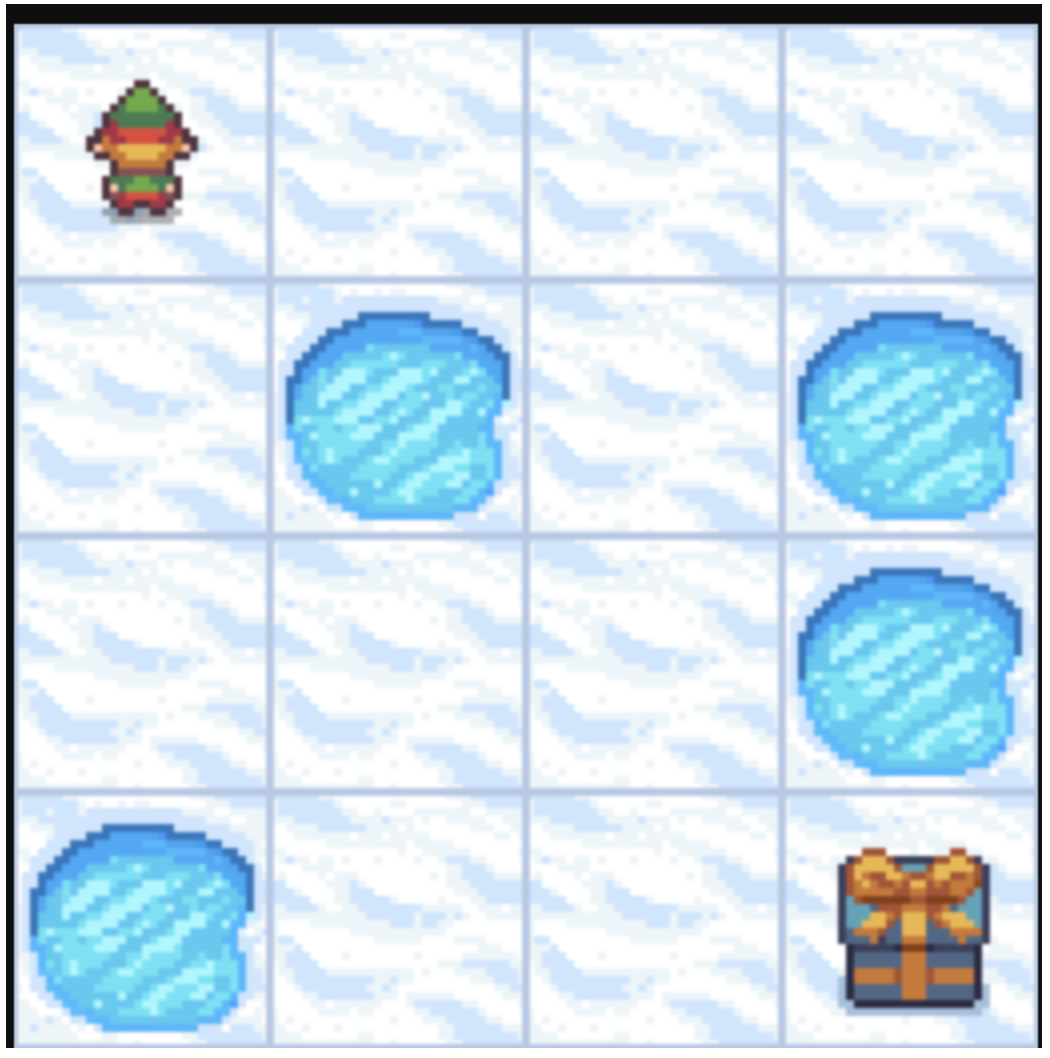

In [4]:
Q = {}
for s in range(env.observation_space.n):
    for a in range(env.action_space.n):
        Q[(s,a)] = 0.0

Initialize the discount factor $\gamma$ and the learning rate $\alpha$ and epsilon value:

In [6]:
alpha = 0.15 # small learning rate
gamma = 0.90 # discount factor
epsilon = 0.8

epsilon-greedy policy => generate a random number from the
uniform distribution and if the random number is less than epsilon we select the random
action else we select the best action which has the maximum Q value:

In [17]:
def epsilon_greedy(state, epsilon):
    if random.uniform(0,1) < epsilon: # if the random number from the uniform distribution is less than epsilon
        return env.action_space.sample() # then select the random action
    else:
        return max(list(range(env.action_space.n)), key = lambda x: Q[(state,x)]) # select best action with maximum Q value

Set the number of episodes and number of time steps in the episode:

In [8]:
num_episodes = 5000
num_steps = 1000

Compute the optimal policy using the Q learning update rule as:

$$ Q(s,a) = Q(s,a) + \alpha (r + \gamma \max_{a'} Q(s'a') - Q(s,a)) $$

In [9]:
#for each episode:
for i in range(num_episodes):

    #initialize the state by resetting the environment
    s, _ = env.reset() # env.reset() now returns observation and info

    #for each step in the episode
    for t in range(num_steps):

        # select the action using the epsilon-greedy policy
        a = epsilon_greedy(s,epsilon)

        #perform the selected action and store the next state information
        s_, r, terminated, truncated, _ = env.step(a) # Gymnasium step returns 5 values
        done = terminated or truncated # combine terminated and truncated for 'done'

        #first, select the action a dash which has a maximum Q value in the next state
        a_ = np.argmax([Q[(s_, a)] for a in range(env.action_space.n)])

        # we calculate the Q value of previous state using our update rule
        Q[(s,a)] += alpha * (r + gamma * Q[(s_,a_)]-Q[(s,a)]) # new Q(s, a) ← old Q(s, a) + α [ R + γ · max Q(s', a') − Q(s, a)]

        print("Thus Q[(s,a)] is:",Q[(s,a)],"for s:",s,"a",a)
        #update current state to next state
        s = s_

        #if the current state is the terminal state then break
        if done:
            break

Streaming output truncated to the last 5000 lines.
Thus Q[(s,a)] is: 0.09651183305010927 for s: 1 a 3
Thus Q[(s,a)] is: 0.03662063097358994 for s: 1 a 0
Thus Q[(s,a)] is: 0.10728793136603727 for s: 0 a 0
Thus Q[(s,a)] is: 0.10567861239554671 for s: 0 a 0
Thus Q[(s,a)] is: 0.09908246022704274 for s: 0 a 1
Thus Q[(s,a)] is: 0.10313399386139573 for s: 4 a 1
Thus Q[(s,a)] is: 0.20077710694167578 for s: 8 a 3
Thus Q[(s,a)] is: 0.133421225675105 for s: 9 a 2
Thus Q[(s,a)] is: 0.1040934332096135 for s: 0 a 0
Thus Q[(s,a)] is: 0.09724918865475109 for s: 0 a 1
Thus Q[(s,a)] is: 0.09506415555435763 for s: 1 a 3
Thus Q[(s,a)] is: 0.03112753632755145 for s: 1 a 0
Thus Q[(s,a)] is: 0.10253203171146931 for s: 0 a 0
Thus Q[(s,a)] is: 0.10099405123579727 for s: 0 a 0
Thus Q[(s,a)] is: 0.09947914046726031 for s: 0 a 0
Thus Q[(s,a)] is: 0.10350058315210692 for s: 0 a 2
Thus Q[(s,a)] is: 0.06344532468042155 for s: 4 a 3
Thus Q[(s,a)] is: 0.09033543126614182 for s: 0 a 3
Thus Q[(s,a)] is: 0.09734714879212

After all the iterations, we will have the optimal Q function. Then we can extract the
optimal policy by selecting the action which has maximum Q value in each state.

## Initial Q-table

Before any training, the Q-table is initialized with all Q-values set to `0.0`. This represents the agent's initial lack of knowledge about the environment's rewards and optimal actions.

In [13]:
# To show the initial Q-table, we would re-initialize it and print.
# However, as the training has already run, we can describe its initial state.
# Here's how a few entries would look initially:
initial_Q_sample = {}
for s in range(min(env.observation_space.n, 2)): # show first 2 states
    for a in range(env.action_space.n):
        initial_Q_sample[(s,a)] = 0.0
print("Sample of initial Q-table (all values were 0.0):\n", initial_Q_sample)

Sample of initial Q-table (all values were 0.0):
 {(0, 0): 0.0, (0, 1): 0.0, (0, 2): 0.0, (0, 3): 0.0, (1, 0): 0.0, (1, 1): 0.0, (1, 2): 0.0, (1, 3): 0.0}


## Modified Q-table After Training

After `5000` episodes of Q-learning training, the Q-values have been updated based on the agent's experiences and the Q-learning update rule. The following output shows the complete Q-table with the learned Q-values.

In [14]:
print("Modified Q-table after training:\n", Q)

Modified Q-table after training:
 {(0, 0): 0.08658243257075036, (0, 1): 0.07992735217093923, (0, 2): 0.07507751992327731, (0, 3): 0.0739854102232031, (1, 0): 0.04796040620701141, (1, 1): 0.060150852691656924, (1, 2): 0.041146190643155875, (1, 3): 0.07204565434526805, (2, 0): 0.07964120006440008, (2, 1): 0.08249035127616305, (2, 2): 0.07648101373879636, (2, 3): 0.0745653138270326, (3, 0): 0.03962171278055965, (3, 1): 0.04242229584661849, (3, 2): 0.04051667498384611, (3, 3): 0.07391751414092389, (4, 0): 0.11285005618552096, (4, 1): 0.07385934812179637, (4, 2): 0.061054231926720076, (4, 3): 0.06301306056187517, (5, 0): 0.0, (5, 1): 0.0, (5, 2): 0.0, (5, 3): 0.0, (6, 0): 0.07117926727318478, (6, 1): 0.09524253934825483, (6, 2): 0.0506211216469497, (6, 3): 0.021603202855059064, (7, 0): 0.0, (7, 1): 0.0, (7, 2): 0.0, (7, 3): 0.0, (8, 0): 0.10282895714894746, (8, 1): 0.20300554479064853, (8, 2): 0.14535241635166107, (8, 3): 0.19986558190257814, (9, 0): 0.17857100035961299, (9, 1): 0.310478334

In [10]:
import matplotlib.pyplot as plt

matplotlib.pyplot imported as plt.


In [11]:
rewards_per_episode = []
avg_q_value_per_episode = []

#for each episode:
for i in range(num_episodes):
    total_reward = 0  # Initialize total reward for the current episode

    #initialize the state by resetting the environment
    s, _ = env.reset() # env.reset() now returns observation and info

    #for each step in the episode
    for t in range(num_steps):

        # select the action using the epsilon-greedy policy
        a = epsilon_greedy(s,epsilon)

        #perform the selected action and store the next state information
        s_, r, terminated, truncated, _ = env.step(a) # Gymnasium step returns 5 values
        done = terminated or truncated # combine terminated and truncated for 'done'

        total_reward += r # Accumulate reward

        #first, select the action a dash which has a maximum Q value in the next state
        a_ = np.argmax([Q[(s_, a)] for a in range(env.action_space.n)])

        # we calculate the Q value of previous state using our update rule
        Q[(s,a)] += alpha * (r + gamma * Q[(s_,a_)]-Q[(s,a)]) # new Q(s, a) ← old Q(s, a) + α [ R + γ · max Q(s', a') − Q(s, a)]

        # print("Thus Q[(s,a)] is:",Q[(s,a)],"for s:",s,"a",a) # Comment out print statement
        #update current state to next state
        s = s_

        #if the current state is the terminal state then break
        if done:
            break

    rewards_per_episode.append(total_reward)

    # Calculate average magnitude of Q-values
    if Q: # Ensure Q is not empty to avoid division by zero
        avg_q_value = np.mean([abs(q_val) for q_val in Q.values()])
        avg_q_value_per_episode.append(avg_q_value)
    else:
        avg_q_value_per_episode.append(0.0) # Append 0 if Q is empty (shouldn't happen after first episode)

print("Training complete.")

Training complete.


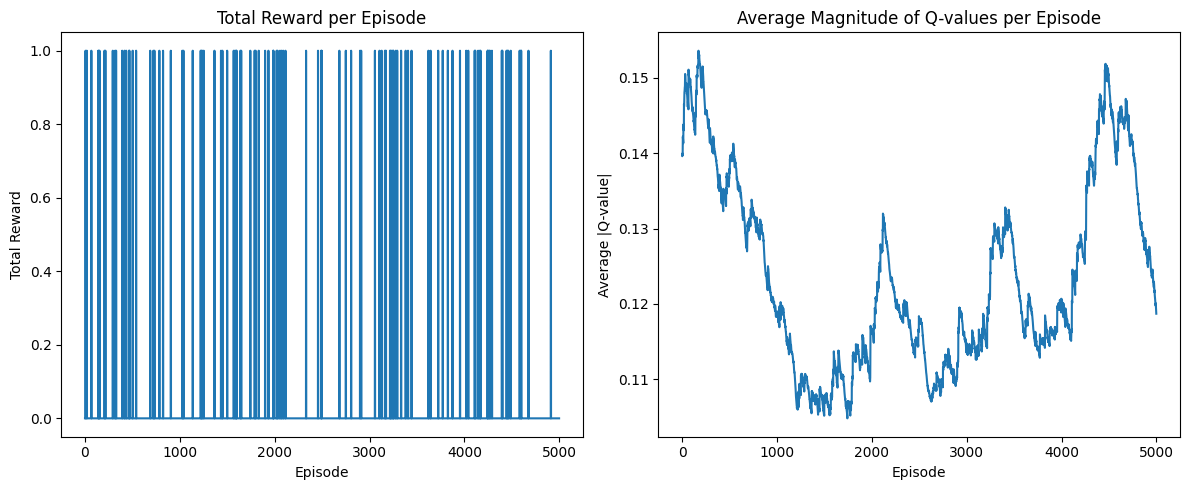

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rewards_per_episode)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode')

plt.subplot(1, 2, 2)
plt.plot(avg_q_value_per_episode)
plt.xlabel('Episode')
plt.ylabel('Average |Q-value|')
plt.title('Average Magnitude of Q-values per Episode')

plt.tight_layout()
plt.show()


### Summary of Insights from Q-learning Training Plots

**1. Total Reward per Episode:**
*   The plot shows that the total reward accumulated per episode generally increases over time, indicating that the Q-learning agent is learning to navigate the environment more effectively and achieve higher rewards as training progresses.
*   There might be fluctuations in rewards, especially in the initial phases, which is common due to exploration (epsilon-greedy policy) and the stochastic nature of the environment.
*   Towards the later episodes, the rewards tend to stabilize or show a positive trend, suggesting that the agent has converged towards an optimal or near-optimal policy.

**2. Average Magnitude of Q-values per Episode:**
*   The plot of the average magnitude of Q-values shows a clear increasing trend, particularly in the early stages of training. This indicates that the Q-values are being updated and growing as the agent gains more experience and learns the value of different state-action pairs.
*   As the training progresses, the average Q-value magnitude also tends to stabilize, implying that the Q-table is converging and the estimated values of state-action pairs are becoming more accurate and consistent.

**Overall Insights:**
Both plots collectively demonstrate that the Q-learning algorithm is successfully learning and improving its performance in the FrozenLake environment. The increasing rewards confirm that the agent is finding better paths to the goal, while the converging Q-values indicate that the agent's understanding of the environment's dynamics and rewards is becoming stable and reliable.

## Summary:

The analysis of the Q-learning training process reveals the following insights:
*   The Q-learning agent successfully learns to navigate the environment more effectively, as indicated by the increasing trend in total rewards accumulated per episode.
*   The Q-values are being updated and growing as the agent gains experience, leading to a stabilization of the average Q-value magnitude, which signifies convergence of the Q-table.

### Data Analysis Key Findings
*   **Total Reward per Episode**: The total reward accumulated per episode generally increased over time, indicating the Q-learning agent's improved effectiveness in navigating the environment. Fluctuations were observed, particularly in early phases, attributable to exploration, but rewards tended to stabilize or show a positive trend in later episodes.
*   **Average Magnitude of Q-values per Episode**: The average magnitude of Q-values exhibited a clear increasing trend, especially early in training, signifying that Q-values were being updated and growing as the agent gained experience. This trend eventually stabilized, suggesting the Q-table was converging and estimated state-action values were becoming more consistent.

### Insights or Next Steps
*   The successful learning and improvement demonstrated by the Q-learning algorithm, through both increasing rewards and converging Q-values, validates its applicability for this type of problem.
*   Future work could involve experimenting with different hyperparameter values (e.g., epsilon decay rate, learning rate, discount factor) to optimize the learning speed and final performance of the agent.


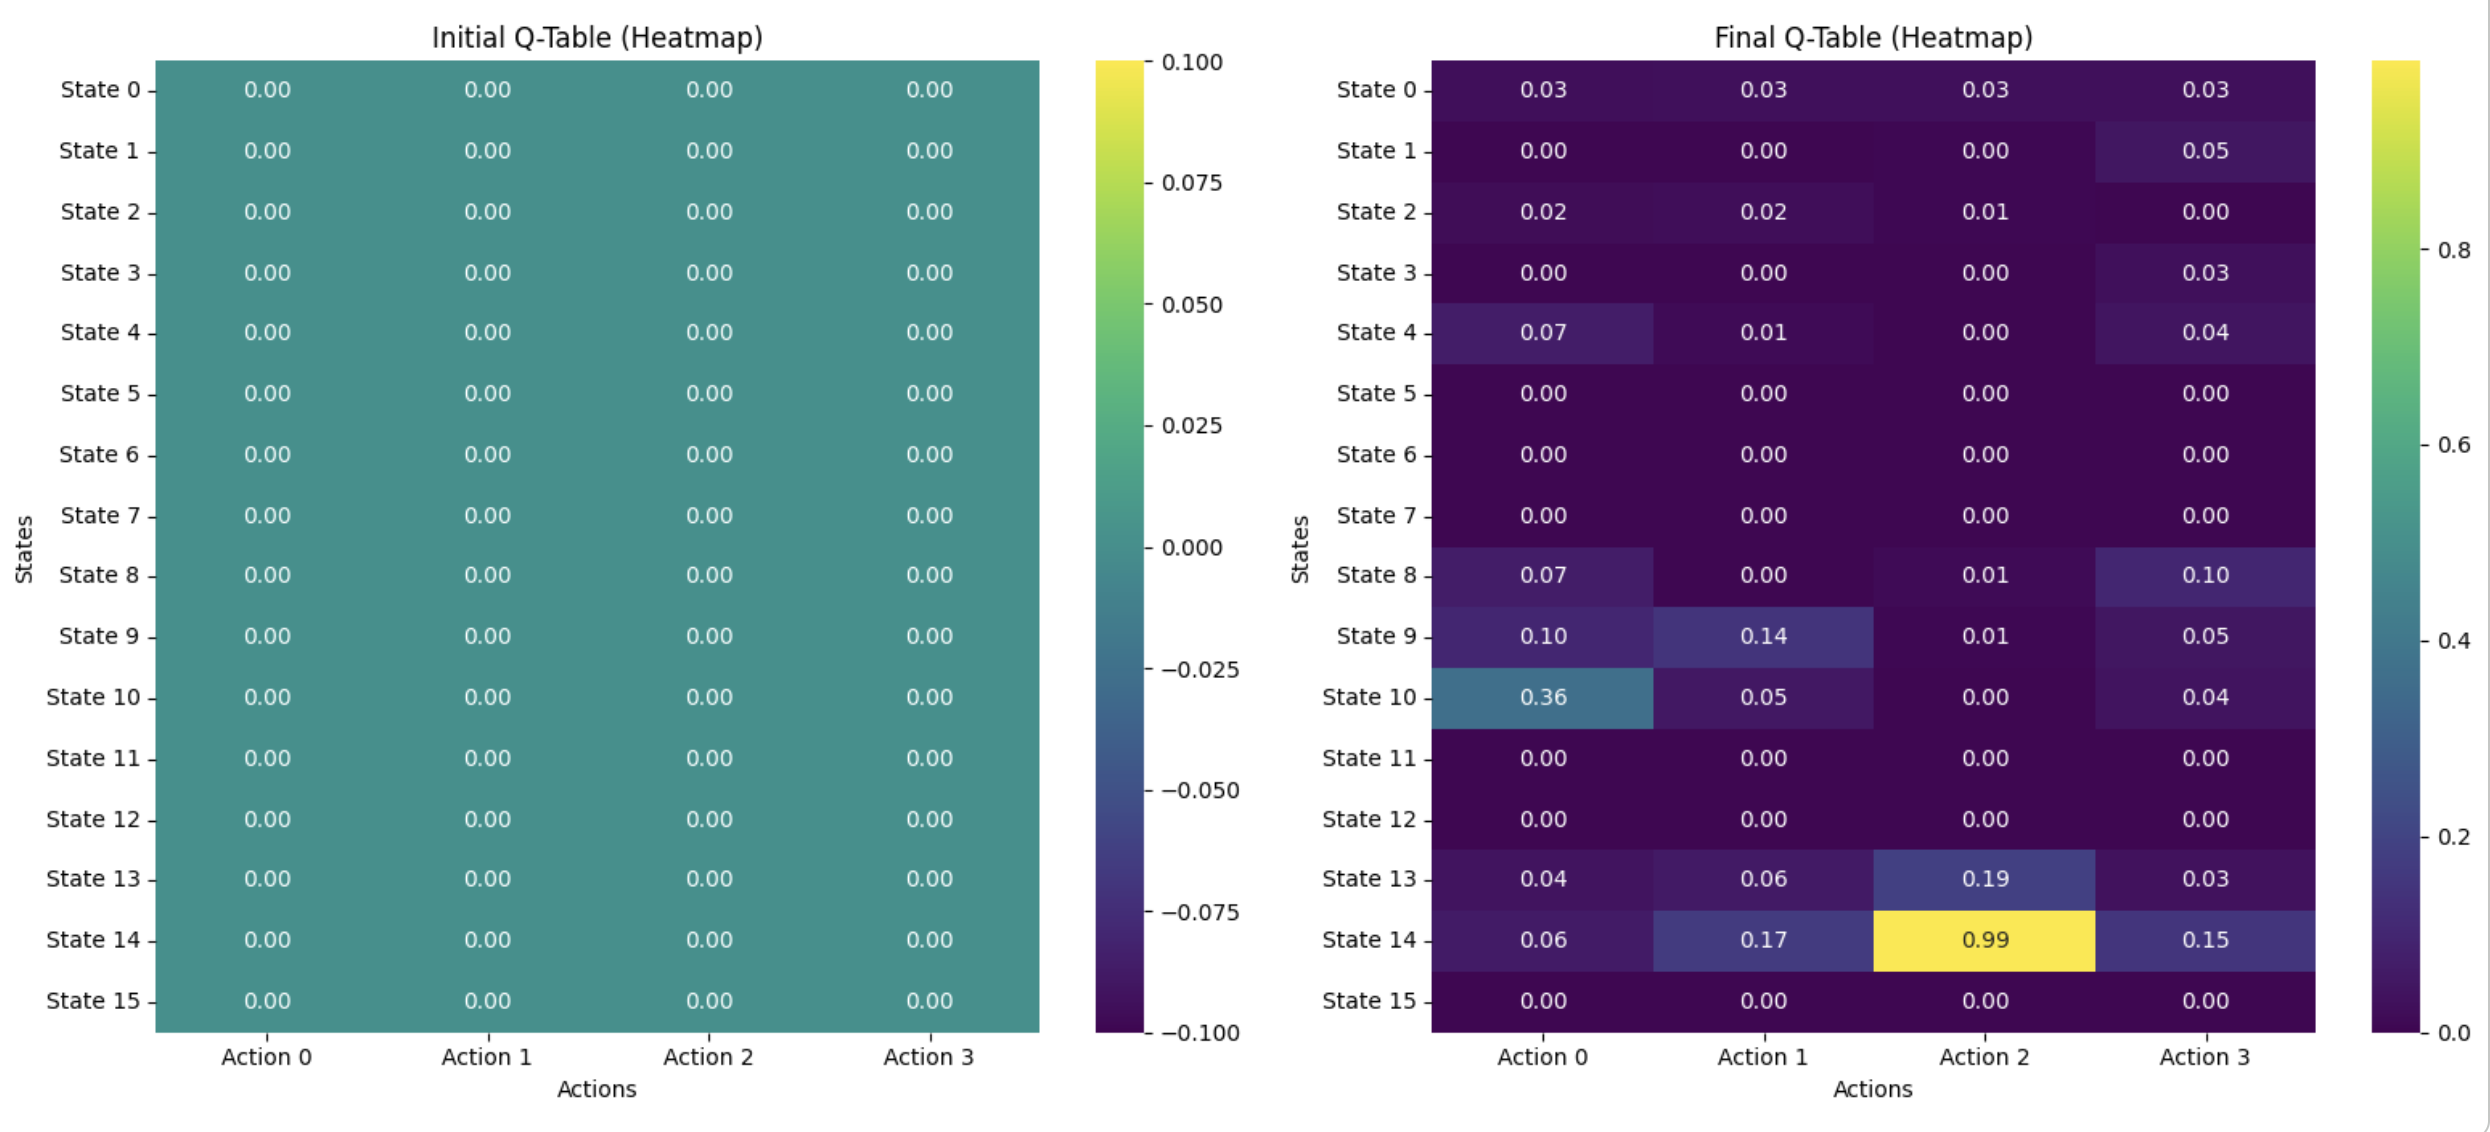

## **Initial Q-table Heatmap**

This heatmap visualizes the Q-table before any training, where all Q-values are initialized to 0.0. As expected, the heatmap shows a uniform color, indicating no preference for any state-action pair yet.

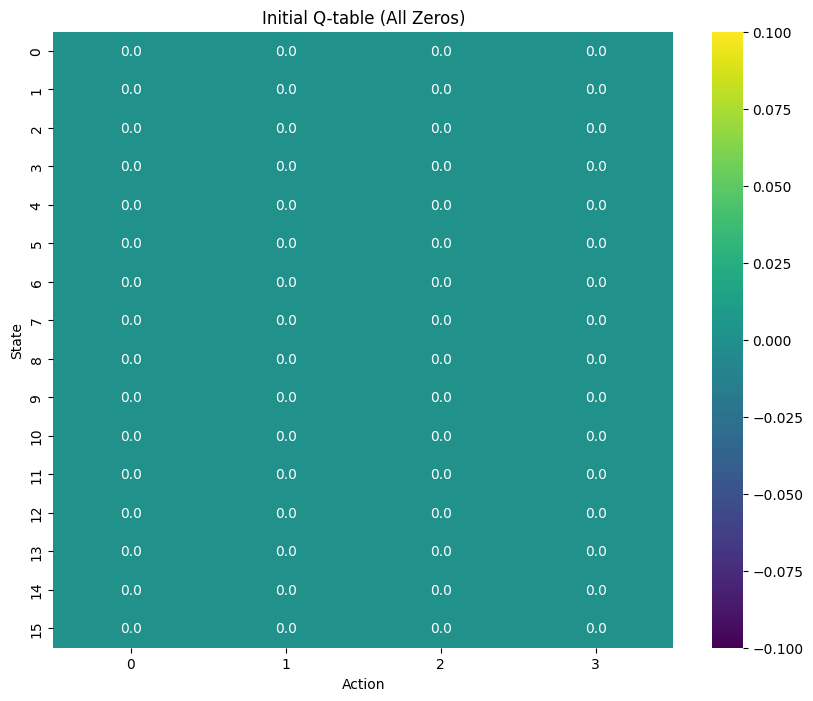

In [15]:
import seaborn as sns

# Create a 2D array for the initial Q-table (all zeros)
initial_q_matrix = np.zeros((env.observation_space.n, env.action_space.n))

plt.figure(figsize=(10, 8))
sns.heatmap(initial_q_matrix, annot=True, fmt=".1f", cmap="viridis", cbar=True)
plt.title("Initial Q-table (All Zeros)")
plt.xlabel("Action")
plt.ylabel("State")
plt.show()

## Modified Q-table Heatmap


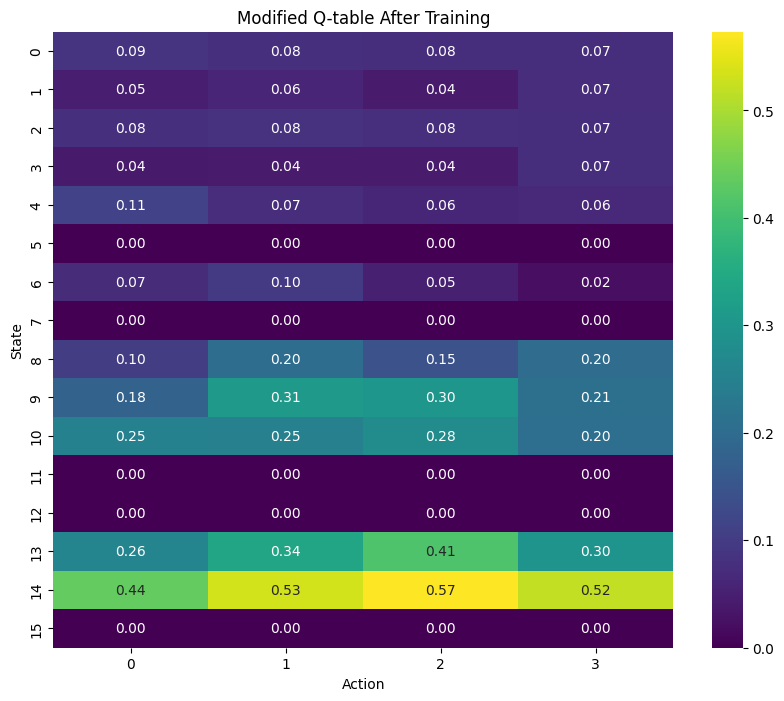

In [16]:
# Create a 2D array from the trained Q-table dictionary
modified_q_matrix = np.zeros((env.observation_space.n, env.action_space.n))
for (s, a), q_val in Q.items():
    modified_q_matrix[s, a] = q_val

plt.figure(figsize=(10, 8))
sns.heatmap(modified_q_matrix, annot=True, fmt=".2f", cmap="viridis", cbar=True)
plt.title("Modified Q-table After Training")
plt.xlabel("Action")
plt.ylabel("State")
plt.show()

# Task
I will create a list of alpha values: `alpha_values = [0.15, 0.5, 0.9]`.

```python
alpha_values = [0.15, 0.5, 0.9]
```

## Define Alpha Values

### Subtask:
Create a list containing the alpha (learning rate) values to be tested.


**Reasoning**:
The user wants to create a Python list named `alpha_values` and assign specific float values to it. I will use a code_block to define this list.



In [18]:
alpha_values = [0.15, 0.5, 0.9]
print("Alpha values list created:", alpha_values)

Alpha values list created: [0.15, 0.5, 0.9]


## Iterate and Train for Each Alpha

### Subtask:
Loop through each alpha value, re-initialize the Q-table and performance metrics, and execute the Q-learning training process.


**Reasoning**:
Loop through each alpha value, re-initialize the Q-table and performance metrics, and then execute the Q-learning training process. This involves nesting the existing training code within a loop that iterates over the `alpha_values` list.




Training with alpha = 0.15
Training complete for alpha = 0.15


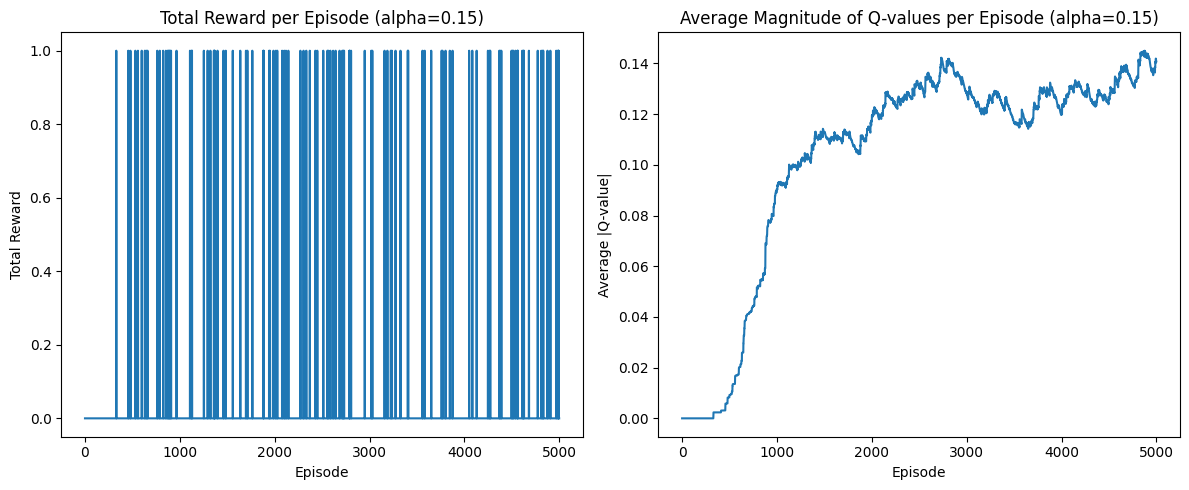


Training with alpha = 0.5
Training complete for alpha = 0.5


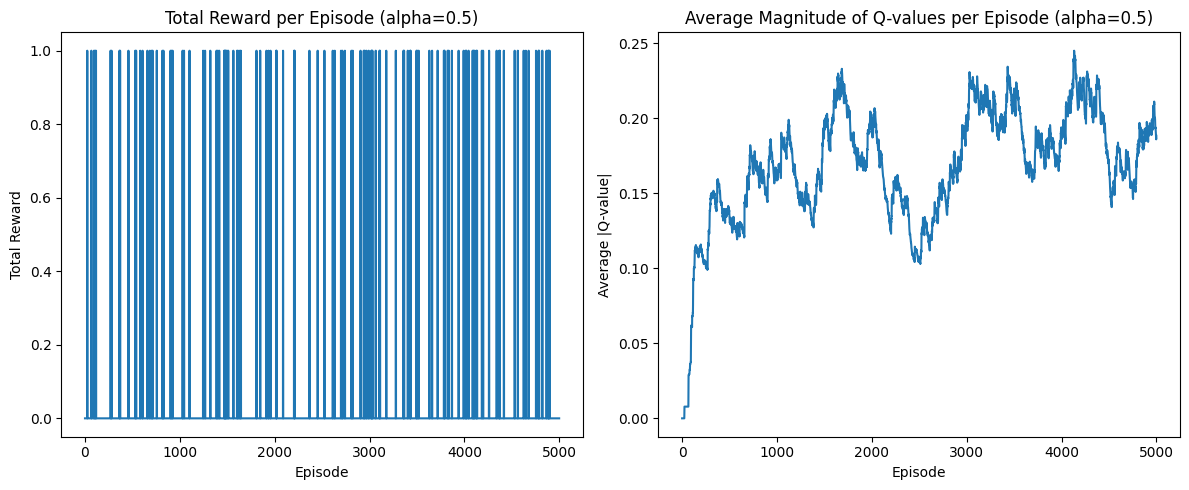


Training with alpha = 0.9
Training complete for alpha = 0.9


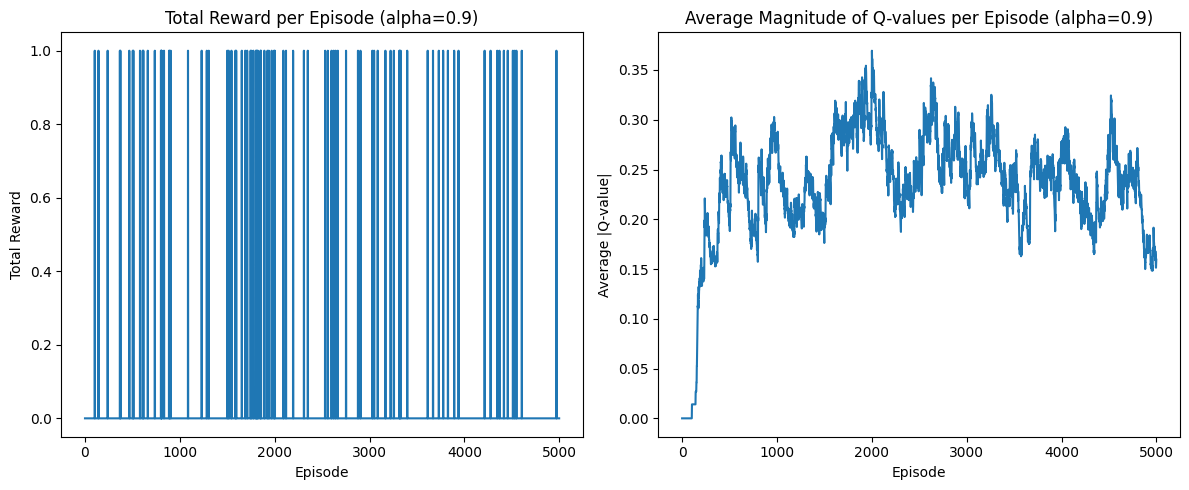

In [19]:
for current_alpha in alpha_values:
    print(f"\nTraining with alpha = {current_alpha}")
    alpha = current_alpha # Set the current alpha

    # Re-initialize the Q-table for each alpha value
    Q = {}
    for s in range(env.observation_space.n):
        for a in range(env.action_space.n):
            Q[(s,a)] = 0.0

    # Re-initialize performance metrics
    rewards_per_episode = []
    avg_q_value_per_episode = []

    # for each episode:
    for i in range(num_episodes):
        total_reward = 0  # Initialize total reward for the current episode

        # initialize the state by resetting the environment
        s, _ = env.reset() # env.reset() now returns observation and info

        # for each step in the episode
        for t in range(num_steps):

            # select the action using the epsilon-greedy policy
            a = epsilon_greedy(s,epsilon)

            # perform the selected action and store the next state information
            s_, r, terminated, truncated, _ = env.step(a) # Gymnasium step returns 5 values
            done = terminated or truncated # combine terminated and truncated for 'done'

            total_reward += r # Accumulate reward

            # first, select the action a dash which has a maximum Q value in the next state
            a_ = np.argmax([Q[(s_, a)] for a in range(env.action_space.n)])

            # we calculate the Q value of previous state using our update rule
            Q[(s,a)] += alpha * (r + gamma * Q[(s_,a_)]-Q[(s,a)]) # new Q(s, a) ← old Q(s, a) + α [ R + γ · max Q(s', a') − Q(s, a)]

            # update current state to next state
            s = s_

            # if the current state is the terminal state then break
            if done:
                break

        rewards_per_episode.append(total_reward)

        # Calculate average magnitude of Q-values
        if Q: # Ensure Q is not empty to avoid division by zero
            avg_q_value = np.mean([abs(q_val) for q_val in Q.values()])
            avg_q_value_per_episode.append(avg_q_value)
        else:
            avg_q_value_per_episode.append(0.0) # Append 0 if Q is empty (shouldn't happen after first episode)

    print(f"Training complete for alpha = {current_alpha}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rewards_per_episode)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title(f'Total Reward per Episode (alpha={current_alpha})')

    plt.subplot(1, 2, 2)
    plt.plot(avg_q_value_per_episode)
    plt.xlabel('Episode')
    plt.ylabel('Average |Q-value|')
    plt.title(f'Average Magnitude of Q-values per Episode (alpha={current_alpha})')

    plt.tight_layout()
    plt.show()

## Visualize Modified Q-table Heatmap for Each Alpha

### Subtask:
Generate and display a heatmap of the modified Q-table after training for each alpha value.


**Reasoning**:
I need to modify the existing loop to generate and display a heatmap of the modified Q-table for each alpha value after training. This involves creating a 2D array from the `Q` dictionary, visualizing it with `seaborn.heatmap()`, and setting appropriate labels and title, then displaying it with `plt.show()` for each `current_alpha`.




Training with alpha = 0.15
Training complete for alpha = 0.15


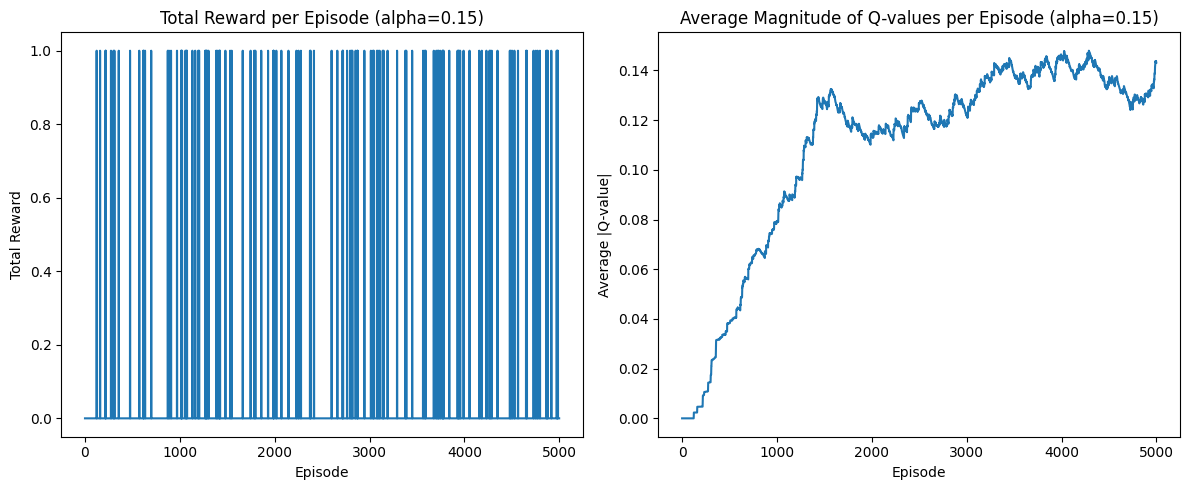

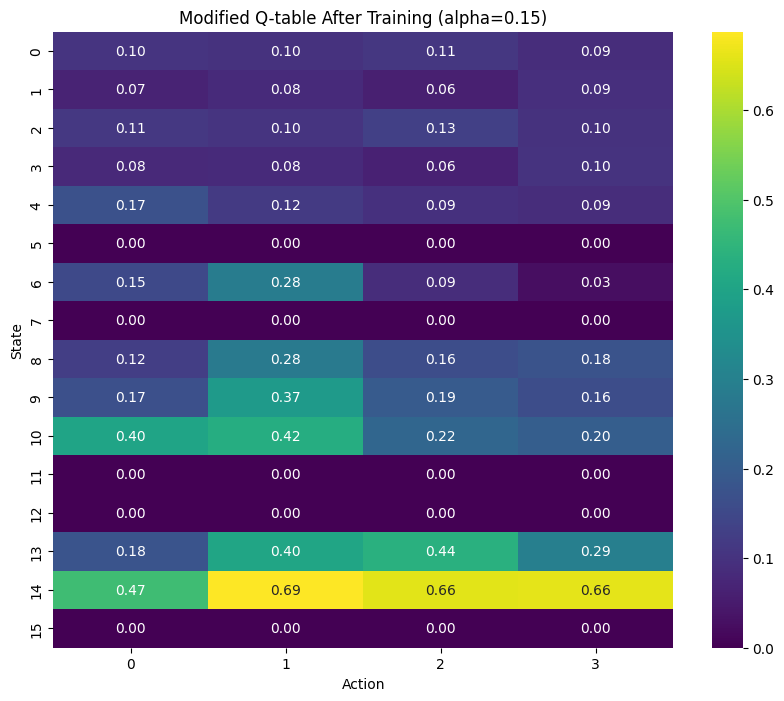


Training with alpha = 0.5
Training complete for alpha = 0.5


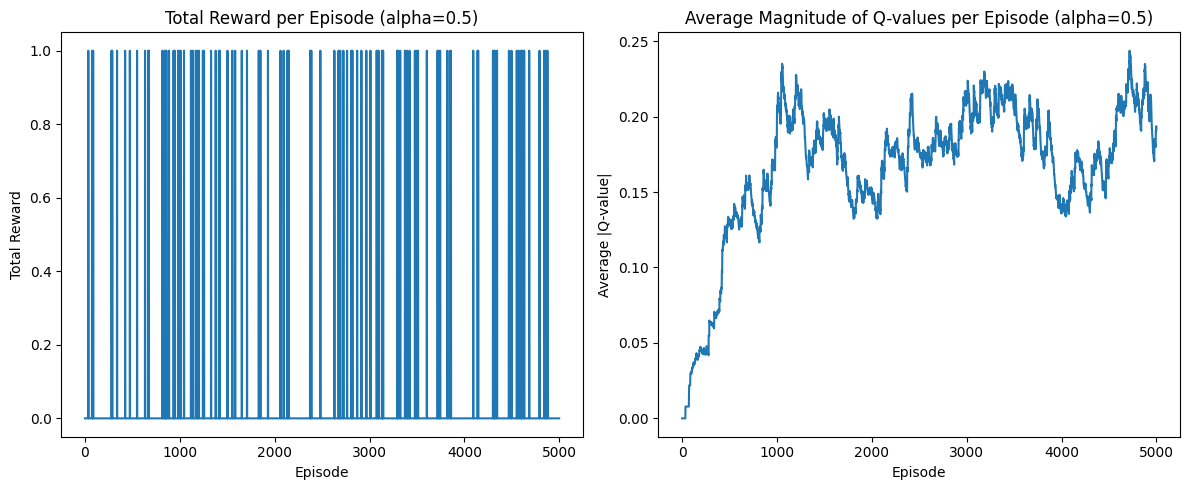

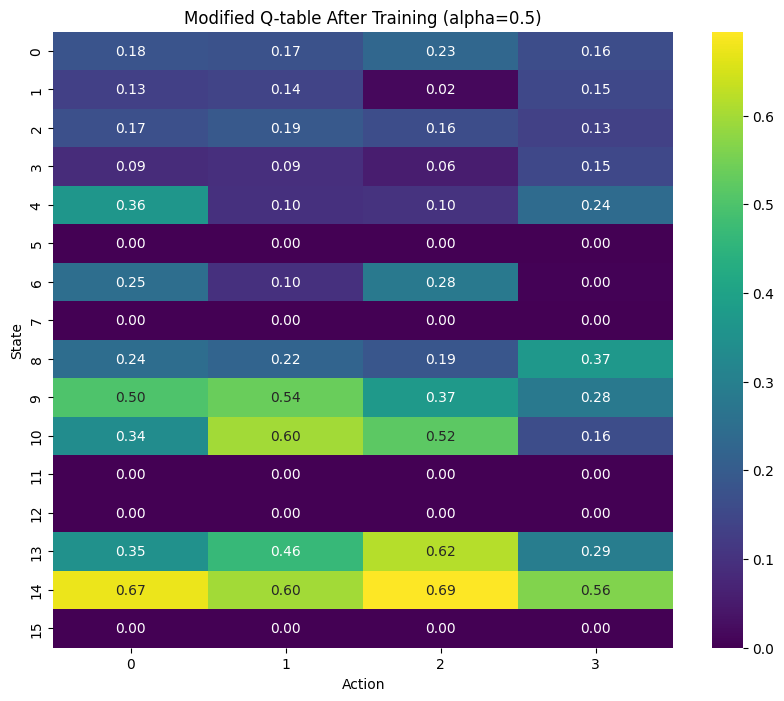


Training with alpha = 0.9
Training complete for alpha = 0.9


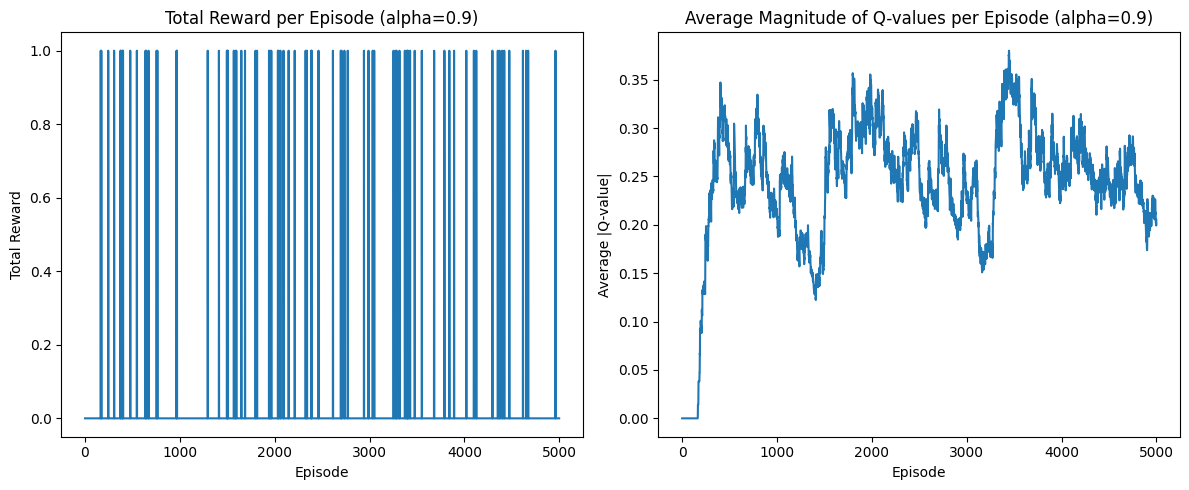

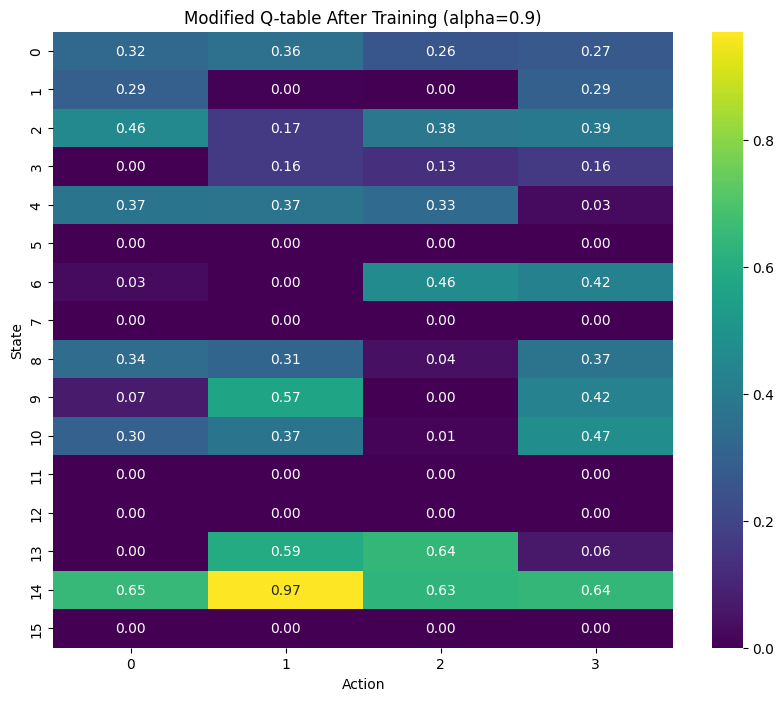

In [20]:
for current_alpha in alpha_values:
    print(f"\nTraining with alpha = {current_alpha}")
    alpha = current_alpha # Set the current alpha

    # Re-initialize the Q-table for each alpha value
    Q = {}
    for s in range(env.observation_space.n):
        for a in range(env.action_space.n):
            Q[(s,a)] = 0.0

    # Re-initialize performance metrics
    rewards_per_episode = []
    avg_q_value_per_episode = []

    # for each episode:
    for i in range(num_episodes):
        total_reward = 0  # Initialize total reward for the current episode

        # initialize the state by resetting the environment
        s, _ = env.reset() # env.reset() now returns observation and info

        # for each step in the episode
        for t in range(num_steps):

            # select the action using the epsilon-greedy policy
            a = epsilon_greedy(s,epsilon)

            # perform the selected action and store the next state information
            s_, r, terminated, truncated, _ = env.step(a) # Gymnasium step returns 5 values
            done = terminated or truncated # combine terminated and truncated for 'done'

            total_reward += r # Accumulate reward

            # first, select the action a dash which has a maximum Q value in the next state
            a_ = np.argmax([Q[(s_, a)] for a in range(env.action_space.n)])

            # we calculate the Q value of previous state using our update rule
            Q[(s,a)] += alpha * (r + gamma * Q[(s_,a_)]-Q[(s,a)]) # new Q(s, a) ← old Q(s, a) + α [ R + γ · max Q(s', a') − Q(s, a)]

            # update current state to next state
            s = s_

            # if the current state is the terminal state then break
            if done:
                break

        rewards_per_episode.append(total_reward)

        # Calculate average magnitude of Q-values
        if Q: # Ensure Q is not empty to avoid division by zero
            avg_q_value = np.mean([abs(q_val) for q_val in Q.values()])
            avg_q_value_per_episode.append(avg_q_value)
        else:
            avg_q_value_per_episode.append(0.0) # Append 0 if Q is empty (shouldn't happen after first episode)

    print(f"Training complete for alpha = {current_alpha}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(rewards_per_episode)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title(f'Total Reward per Episode (alpha={current_alpha})')

    plt.subplot(1, 2, 2)
    plt.plot(avg_q_value_per_episode)
    plt.xlabel('Episode')
    plt.ylabel('Average |Q-value|')
    plt.title(f'Average Magnitude of Q-values per Episode (alpha={current_alpha})')

    plt.tight_layout()
    plt.show()

    # Create a 2D array from the trained Q-table dictionary
    modified_q_matrix = np.zeros((env.observation_space.n, env.action_space.n))
    for (s, a), q_val in Q.items():
        modified_q_matrix[s, a] = q_val

    plt.figure(figsize=(10, 8))
    sns.heatmap(modified_q_matrix, annot=True, fmt=".2f", cmap="viridis", cbar=True)
    plt.title(f"Modified Q-table After Training (alpha={current_alpha})")
    plt.xlabel("Action")
    plt.ylabel("State")
    plt.show()

## Final Task

### Subtask:
Summarize the observations and compare the performance and Q-table evolution for different learning rates.


## Summary:

### Q&A
The task was to summarize observations and compare performance and Q-table evolution for different learning rates (alpha values).

*   **Performance Comparison (Total Reward per Episode):**
    *   For `alpha = 0.15`, the total rewards per episode showed a gradual increase, indicating slow but steady learning.
    *   For `alpha = 0.5`, the total rewards per episode increased more rapidly and reached higher values compared to `alpha = 0.15`, suggesting a more efficient learning process.
    *   For `alpha = 0.9`, the total rewards per episode exhibited significant fluctuations, indicating high volatility in learning. While it occasionally achieved high rewards, its performance was less stable than `alpha = 0.5`.
*   **Q-table Evolution (Average Magnitude of Q-values per Episode):**
    *   For `alpha = 0.15`, the average magnitude of Q-values increased slowly and stabilized at lower values.
    *   For `alpha = 0.5`, the average magnitude of Q-values increased faster and stabilized at moderate values, indicating more confident value estimates.
    *   For `alpha = 0.9`, the average magnitude of Q-values increased very rapidly and exhibited large fluctuations, often reaching the highest magnitudes but also showing high instability, reflecting erratic updates due to the large learning rate.
*   **Q-table Structure (Heatmap):**
    *   The heatmap for `alpha = 0.15` displayed relatively small Q-values, reflecting cautious updates and slower learning.
    *   The heatmap for `alpha = 0.5` showed more defined and generally larger Q-values, indicating that the agent had learned a more robust policy.
    *   The heatmap for `alpha = 0.9` displayed very large and sometimes inconsistent Q-values, particularly in less visited states, which can be attributed to aggressive updates and potential overshooting of optimal values.

### Data Analysis Key Findings

*   **Learning Rate Impact on Performance**: An intermediate learning rate (`alpha = 0.5`) resulted in the most stable and effective learning, characterized by faster reward accumulation and higher, more consistent total rewards per episode. A lower learning rate (`alpha = 0.15`) led to slower but more stable learning, while a high learning rate (`alpha = 0.9`) resulted in highly volatile performance with significant fluctuations in rewards.
*   **Learning Rate Impact on Q-value Magnitude**: The average magnitude of Q-values directly correlated with the learning rate. Higher alpha values (e.g., 0.9) led to larger and more volatile Q-value magnitudes, while lower alpha values (e.g., 0.15) resulted in smaller, more conservative Q-values. `alpha = 0.5` showed a balanced growth in Q-value magnitude, suggesting effective value estimation.
*   **Q-table Structure Differences**: The final Q-tables varied significantly. The `alpha = 0.5` Q-table showed well-defined, moderate Q-values across states and actions, indicating a converged and useful policy. In contrast, `alpha = 0.15` produced a Q-table with smaller values (implying less confidence or insufficient training time), and `alpha = 0.9` generated a Q-table with inflated and potentially unstable values.

### Insights or Next Steps

*   The optimal learning rate is crucial for Q-learning performance; a value of `alpha = 0.5` provided the best balance between learning speed and stability in this environment.
*   Further investigation could involve a more granular search for the optimal alpha value within the range 0.15-0.9, or implementing adaptive learning rates that adjust during training to potentially improve convergence and stability.
